Modules import

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.animation as animation

import seaborn as sns

import numpy as np
import pandas as pd

import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from statsmodels.nonparametric.smoothers_lowess import lowess

Font definition

In [2]:
font_path = "/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Regular.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Work Sans"
work_sans_title = fm.FontProperties(fname="/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Bold.ttf", size=16)
work_sans_axis = fm.FontProperties(fname="/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Regular.ttf", size=12)

Dataset import

it contains the monthly anomalies of the global surface temperature GISTEMP.

from Jan 1880 - Aug 2026; 1760 months; 

latitude: from -89° to 89° with a grid of 2° -> a grid of 90 points
longitude: from -179° to 179° -> a grid of 180 points

tempanomaly has dimension (time, lat, lon)

In [3]:
gridded_data = xr.open_dataset("/Users/anvi/Desktop/climate_science/GISS_Surface_Temperature_Analysis_v4/data/Gridded/NetCDF/gistemp1200_GHCNv4_ERSSTv5.nc")
print(gridded_data)

<xarray.Dataset> Size: 114MB
Dimensions:      (time: 1760, nv: 2, lat: 90, lon: 180)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-08-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-09-08 02:31:15 by SBBX_to_nc 2.0 - ILAND=1200,...


In [4]:
gridded_data

<xarray.Dataset> Size: 114MB
Dimensions:      (time: 1760, nv: 2, lat: 90, lon: 180)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-08-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-09-08 02:31:15 by SBBX_to_nc 2.0 - ILAND=1200,...

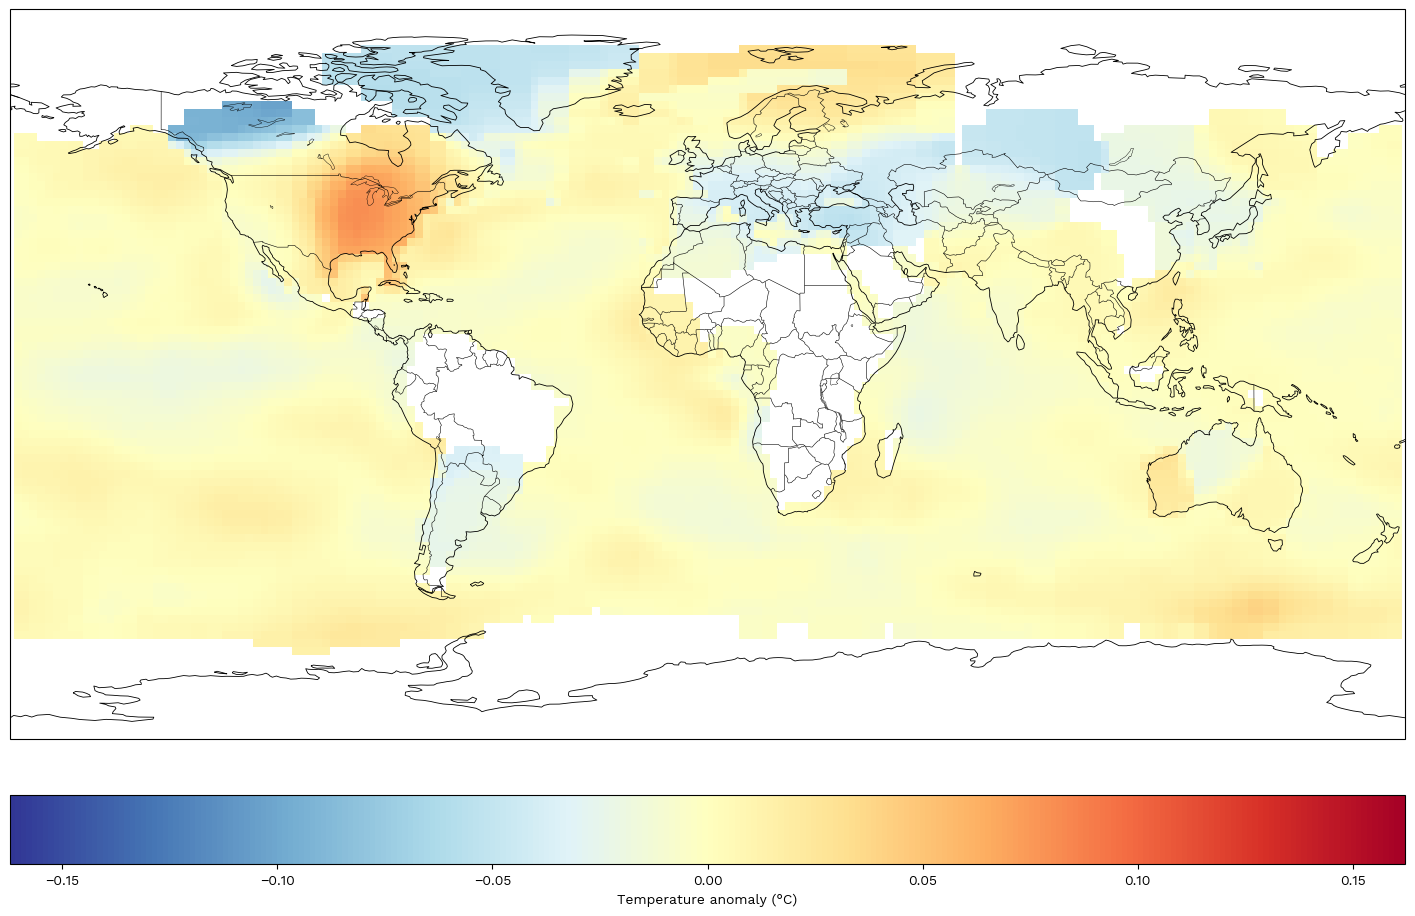

In [5]:
temp_anomaly = gridded_data["tempanomaly"]*0.01
limit = np.nanmax(np.abs(temp_anomaly.values))

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(18, 12), subplot_kw={"projection": projection})

image = ax.imshow(temp_anomaly.isel(time=0), extent=[
        gridded_data.lon.min(),
        gridded_data.lon.max(),
        gridded_data.lat.min(),
        gridded_data.lat.max()
    ],
    origin="lower", cmap="RdYlBu_r", vmin=-limit, vmax=limit, transform=projection, aspect="auto")

ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="black")
ax.add_feature(cfeature.LAKES, facecolor="none", edgecolor="black", linewidth=0.3)
ax.set_global()

colorbar = fig.colorbar(image, ax=ax, orientation="horizontal", pad=0.06)
colorbar.set_label("Temperature anomaly (°C)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
title = ax.set_title("")

def update(frame):
    image.set_data(temp_anomaly.isel(time=frame).values)
    date = temp_anomaly.time.isel(time=frame)

    title.set_text(
        f"Global Temperature Anomaly - "
        f"{date.dt.strftime('%B %Y').item()}"
    )
    return image, title

animation_plot = animation.FuncAnimation(fig, update, frames=len(temp_anomaly.time), interval=50, blit=False)

plt.show()

In [ ]:
animation_plot.save("/Users/anvi/Desktop/climate_science/notebook/GISS/out/gifs/global_temperature_anomalies.gif", writer="pillow", fps=24)